# Block 03a - advection interpolation for accumulations

An hourly total from 5-minute scans counts each scan for five minutes, so a moving cell
leaves beads. Interpolating along the motion between scans (the session's `interpolate`,
here `os_nowcasting.interp`) gives the swath. OpenMRG's radar is 5-minute instantaneous
reflectivity, the case the method is for (OpenRainER's 15-min product is already an
accumulation). The study scores both totals at the city gauges over five events.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import viz_style as vs
from os_nowcasting import data, grid, nowcast, plots, products, verify
vs.use_style()

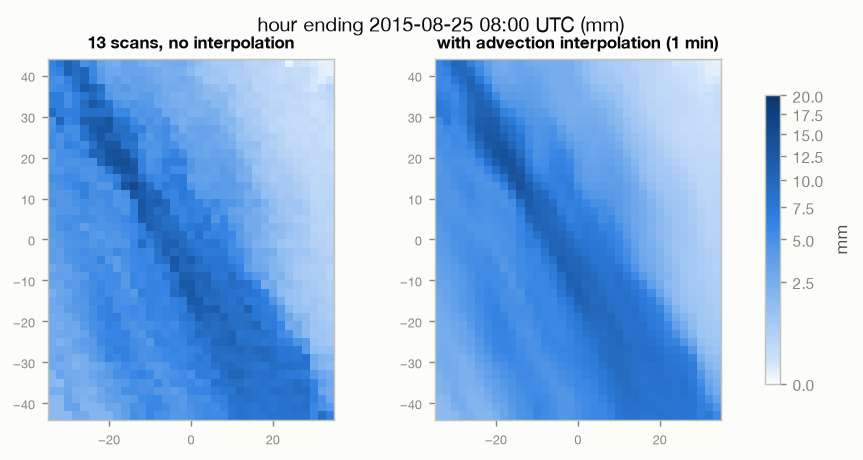

In [2]:
from os_nowcasting import interp
NET, STEP = "openmrg", 5
radar = data.radar(NET, "2015-08-25 05:00", "2015-08-25 09:00")
rate, meta = grid.to_pysteps(radar, STEP)
times = pd.DatetimeIndex(radar.time.values)
end = times.get_loc(pd.Timestamp("2015-08-25 08:00"))
scans = rate[end - 12:end + 1]
plain = interp.hourly_total(scans, meta, interpolate=False)
adv = interp.hourly_total(scans, meta, interpolate=True)
fig, axes = plots.row([plain, adv], ["13 scans, no interpolation", "with advection interpolation (1 min)"], meta, vmax=20, size=4, label="mm")
fig.suptitle("hour ending 2015-08-25 08:00 UTC (mm)", fontsize=11);

In [3]:
g = data.points(NET, "2015-08-25 05:00", "2015-08-25 09:00", "city")
gh = g.resample(time="1h", closed="right", label="right").sum(min_count=12).sel(time="2015-08-25 08:00")
from os_nowcasting.study import gauge_cells
c = gauge_cells(g, data.grid_for(NET))
pd.DataFrame({"gauge": gh.values, "plain": plain.ravel()[c], "advection": adv.ravel()[c]},
             index=g.station.values).round(2)

,gauge,plain,advection
city_Jarn,7.8,10.39,10.44
city_Torp,4.4,6.49,6.59
city_Bergsj,3.1,3.62,3.88
city_Torsl,11.5,6.54,8.62
city_Chalm,5.3,5.87,6.35
city_Tole,4.8,6.55,7.08
city_Barl,5.9,9.93,9.67
city_Drakeg,3.4,5.87,6.28
city_Lbom,4.2,5.94,6.27
city_Askim,9.4,10.93,10.73


In [4]:
import pathlib
p = pathlib.Path("../results/advection_interpolation.csv")
pd.read_csv(p) if p.exists() else "run the study first"

,network,method,subset,n,rmse_mm,mae_mm,corr,bias_pct
0,openmrg,advection,all hours,1489,1.1532,0.4329,0.7306,-3.9761
1,openmrg,advection,gauge >= 1 mm,320,2.1796,1.4105,0.5755,-19.1388
2,openmrg,plain,all hours,1489,1.1873,0.4436,0.7160,-5.2220
3,openmrg,plain,gauge >= 1 mm,320,2.2451,1.4556,0.5578,-20.1114
